# Decision Tree on Diabetes 130-US Hospitals Dataset

This notebook implements **binary** readmission prediction (Readmitted vs. Not Readmitted), aligned with the Glucose Gang guide: explicit removal of 5 features, 60/20/20 split, StandardScaler, GridSearchCV over odd k, and evaluation with confusion matrix, learning curve, and prediction time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, PredefinedSplit
from sklearn.tree import ( DecisionTreeClassifier, plot_tree )
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_fscore_support
)

DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data_cleaned.csv"
RANDOM_STATE = 42

# Features to remove per Glucose Gang guide (high missing / not useful for KNN)
GUIDE_DROP_COLS = ["weight", "payer_code", "medical_specialty", "max_glu_serum", "A1Cresult"]

In [2]:
# Load data and apply Glucose Gang data cleaning: drop 5 features, then drop rows with any remaining missing.
df = pd.read_csv(DATA_PATH, na_values=["?", "None"], low_memory=False)
print(f"Shape after load: {df.shape}")

# Remove the 5 features identified in the guide
df = df.drop(columns=[c for c in GUIDE_DROP_COLS if c in df.columns], errors="ignore")
print(f"After dropping {GUIDE_DROP_COLS}: {df.shape}")

# Drop rows with any remaining missing values
df = df.dropna()
print(f"After dropna(): {df.shape}")

# Binary target: "Not Readmitted" (0) vs "Readmitted" (1 = <30 or >30 days)
df["readmitted_binary"] = (df["readmitted"] != "NO").astype(int)
print(f"\nBinary target distribution:\n{df['readmitted_binary'].value_counts()}")
print(f"  Not Readmitted (0): {(df['readmitted_binary'] == 0).sum()}")
print(f"  Readmitted (1):     {(df['readmitted_binary'] == 1).sum()}")

Shape after load: (101766, 45)
After dropping ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']: (101766, 43)
After dropna(): (98053, 43)

Binary target distribution:
readmitted_binary
0    52338
1    45715
Name: count, dtype: int64
  Not Readmitted (0): 52338
  Readmitted (1):     45715


In [3]:
# Drop identifier columns (not predictive); use binary target
id_cols = ["encounter_id", "patient_nbr"]
df = df.drop(columns=id_cols, errors="ignore")

target_col = "readmitted_binary"
y = df[target_col]
X = df.drop(columns=[target_col, "readmitted"], errors="ignore")  # drop original multiclass target too

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(cat_cols))

Numeric features: 11
Categorical features: 31


In [4]:
# Preprocessing pipeline: impute (for any remaining missing), encode categoricals, scale numeric.
# Note: Scaling is not required for Decision Trees, but we keep it for consistency across models.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, cat_cols),
], remainder="drop")

In [5]:
# 60/20/20 split (Train / Validation / Test) — stratified by binary target
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# Fit preprocessor on train only, then transform train/val/test (avoids leakage)
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Processed feature dimension: {X_train.shape[1]}")

Train: 58831, Validation: 19611, Test: 19611
Processed feature dimension: 2153


In [6]:
# Hyperparameter tuning: GridSearchCV for Decision Tree

# Use validation set for model selection (PredefinedSplit: train=-1, val=0)
n_train = len(X_train)
n_val = len(X_val)

split_index = np.concatenate([np.full(n_train, -1), np.zeros(n_val)])
ps = PredefinedSplit(split_index)

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([
    y_train.values if hasattr(y_train, "values") else y_train,
    y_val.values if hasattr(y_val, "values") else y_val
])

# Decision Tree hyperparameters
# param_grid = {
#     "max_depth": [3, 5, 7, 10, None],
#     "min_samples_leaf": [1, 5, 10, 20],
#     "criterion": ["gini", "entropy"]
# }

# Random Forest hyperparameters
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt"],
    "criterion": ["gini"]
}

# grid = GridSearchCV(
#     DecisionTreeClassifier(random_state=RANDOM_STATE),
#     param_grid=param_grid,
#     cv=ps,
#     scoring="accuracy",
#     refit=True,
#     n_jobs=-1,
# )

# Random Forest hyperparameters
grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=ps,
    scoring="accuracy",
    refit=True,
    n_jobs=-1
)

grid.fit(X_train_val, y_train_val)

best_params = grid.best_params_
print(f"Best parameters: {best_params} (validation accuracy: {grid.best_score_:.4f})")

print("Validation accuracy per setting:")
for mean_score, params in zip(grid.cv_results_["mean_test_score"], grid.cv_results_["params"]):
    print(f"  {params}: {mean_score:.4f}")

Best parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100} (validation accuracy: 0.6361)
Validation accuracy per setting:
  {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 50}: 0.5521
  {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}: 0.5666
  {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 50}: 0.5546
  {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}: 0.5717
  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 50}: 0.6081
  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}: 0.6091
  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 50}: 0.59

In [7]:
# Final model: refit best parameters on training set, then evaluate
# final_clf = DecisionTreeClassifier(**grid.best_params_, random_state=RANDOM_STATE)
final_clf = RandomForestClassifier(**grid.best_params_, random_state=RANDOM_STATE)
final_clf.fit(X_train, y_train)
y_test_pred = final_clf.predict(X_test)

# Prediction time
n_test = len(X_test)
t0 = time.perf_counter()
_ = final_clf.predict(X_test)
elapsed = time.perf_counter() - t0
print(f"Prediction time for {n_test} test samples: {elapsed:.6f} s")

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest accuracy: {test_accuracy:.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred, target_names=["Not Readmitted", "Readmitted"]))

Prediction time for 19611 test samples: 0.917370 s

Test accuracy: 0.6341

Classification report (test set):
                precision    recall  f1-score   support

Not Readmitted       0.63      0.76      0.69     10468
    Readmitted       0.64      0.48      0.55      9143

      accuracy                           0.63     19611
     macro avg       0.64      0.62      0.62     19611
  weighted avg       0.64      0.63      0.63     19611



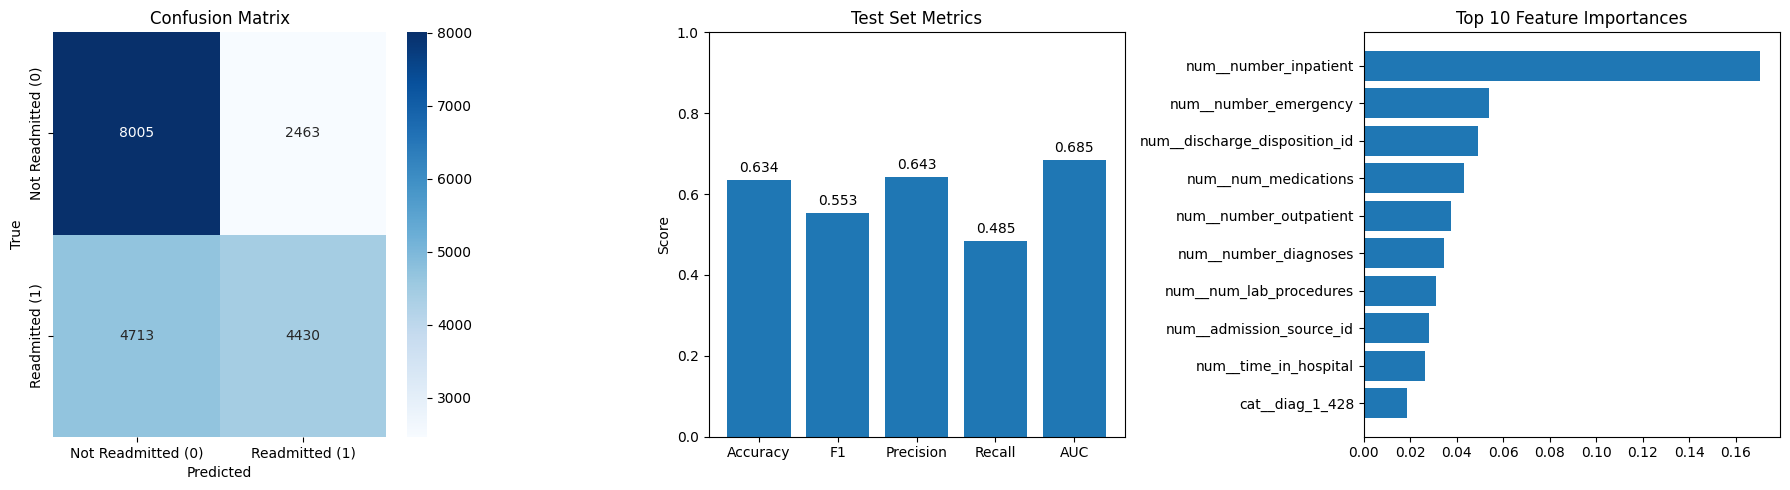

Test metrics: {'Accuracy': '0.6341', 'F1': '0.5525', 'Precision': '0.6427', 'Recall': '0.4845', 'AUC': '0.6850'}


In [8]:
# --- Code Block 3: Evaluation metrics and Decision Tree Interpretability ---

# 1. Confusion matrix
y_test_np = np.asarray(y_test)
cm = confusion_matrix(y_test, y_test_pred)
labels_binary = ["Not Readmitted (0)", "Readmitted (1)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_binary, yticklabels=labels_binary, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix")

# 2. Metrics
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, final_clf.predict_proba(X_test)[:, 1])

metrics = {"Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec, "AUC": auc}

axes[1].bar(metrics.keys(), metrics.values())
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].set_title("Test Set Metrics")

for i, v in enumerate(metrics.values()):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center")

# 3. Feature Importance
importances = final_clf.feature_importances_

feature_names = preprocessor.get_feature_names_out()

indices = np.argsort(importances)[-10:]  # Top 10 features

axes[2].barh(range(len(indices)), importances[indices])
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices])
axes[2].set_title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

print("Test metrics:", {k: f"{v:.4f}" for k, v in metrics.items()})

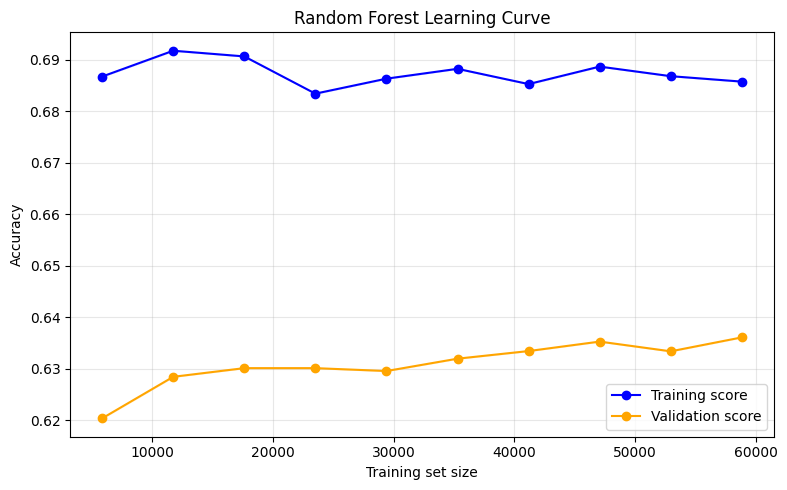

In [9]:
# We use X_train_val and ps (PredefinedSplit) to stay consistent with the GridSearch
train_sizes, train_scores, cv_scores = learning_curve(
    final_clf, X_train_val, y_train_val, cv=ps, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training score")
plt.plot(train_sizes, cv_mean, "o-", color="orange", label="Validation score")

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.title("Random Forest Learning Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Improved Random Forest: class balancing + cost-sensitive learning

To improve minority-class recall, we use **cost-sensitive learning** by setting `class_weight='balanced'`. 
This adjusts the impurity importance of each class inversely proportional to their frequencies in the input data, 
ensuring the tree doesn't ignore the minority "Readmitted" cases just to achieve high overall accuracy.

In [ ]:
classes, counts = np.unique(y_train, return_counts=True)
print("Original class distribution:", dict(zip(classes, counts)))

print("Strategy: Using cost-sensitive learning (class_weight='balanced') instead of oversampling.")

In [10]:
# Improved Random Forest: class balancing + hyperparameter tuning

# param_grid_improved = {
#     "max_depth": [3, 5, 7, 9, 12, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 5],
# }

# grid_improved = GridSearchCV(
#     DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
#     param_grid=param_grid_improved,
#     cv=ps,
#     scoring="accuracy",
#     n_jobs=-1,
# )

param_grid_improved = {
    "n_estimators": [100, 150],
    "max_depth": [15, 20, None],
    "min_samples_leaf": [3, 5, 7],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini"]
}

grid_improved = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid_improved,
    cv=ps,
    scoring="accuracy",
    n_jobs=-1,
)

grid_improved.fit(X_train_val, y_train_val)

print("Best parameters (improved):", grid_improved.best_params_)
print(f"Best validation accuracy: {grid_improved.best_score_:.4f}")

Best parameters (improved): {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'n_estimators': 150}
Best validation accuracy: 0.6370


In [11]:
# Final improved model: evaluate on test set
# final_clf_improved = DecisionTreeClassifier(
#     **grid_improved.best_params_,
#     class_weight="balanced",
#     random_state=RANDOM_STATE
# )
final_clf_improved = RandomForestClassifier(
    **grid_improved.best_params_,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

final_clf_improved.fit(X_train, y_train)
y_test_pred_improved = final_clf_improved.predict(X_test)

test_accuracy_improved = accuracy_score(y_test, y_test_pred_improved)

print(f"Improved — Test accuracy: {test_accuracy_improved:.4f}  (baseline was {test_accuracy:.4f})")

print("\nClassification report (improved, test set):")
print(classification_report(y_test, y_test_pred_improved))

print("Confusion matrix (improved, test set):")
print(confusion_matrix(y_test, y_test_pred_improved))

Improved — Test accuracy: 0.6351  (baseline was 0.6341)

Classification report (improved, test set):
              precision    recall  f1-score   support

           0       0.66      0.66      0.66     10468
           1       0.61      0.61      0.61      9143

    accuracy                           0.64     19611
   macro avg       0.63      0.63      0.63     19611
weighted avg       0.63      0.64      0.63     19611

Confusion matrix (improved, test set):
[[6918 3550]
 [3607 5536]]


In [12]:
# Compare baseline vs balanced model (macro F1 is often better for imbalanced data)
from sklearn.metrics import f1_score
macro_f1_baseline = f1_score(y_test, y_test_pred, average="macro")
macro_f1_improved = f1_score(y_test, y_test_pred_improved, average="macro")
print("Comparison (test set):")
print(f"  Accuracy:  baseline {test_accuracy:.4f}  |  improved {test_accuracy_improved:.4f}")
print(f"  Macro F1:  baseline {macro_f1_baseline:.4f}  |  improved {macro_f1_improved:.4f}")

Comparison (test set):
  Accuracy:  baseline 0.6341  |  improved 0.6351
  Macro F1:  baseline 0.6215  |  improved 0.6332


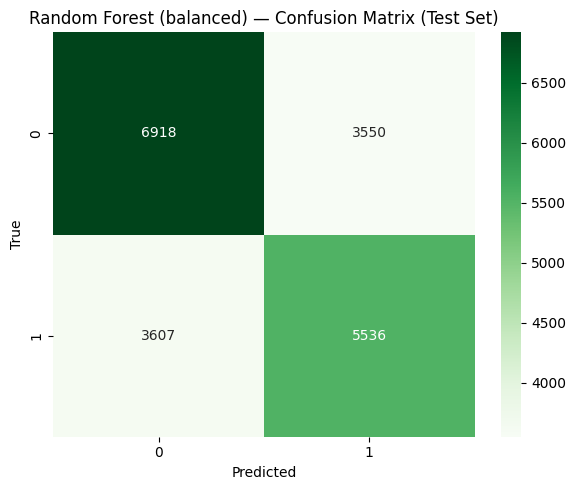

In [13]:
# Confusion matrix heatmap (Random Forest)
classes = sorted(y_test.unique())
cm_rf = confusion_matrix(y_test, y_test_pred_improved)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes, ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Random Forest (balanced) — Confusion Matrix (Test Set)")

plt.tight_layout()
plt.show()

## Visualizations

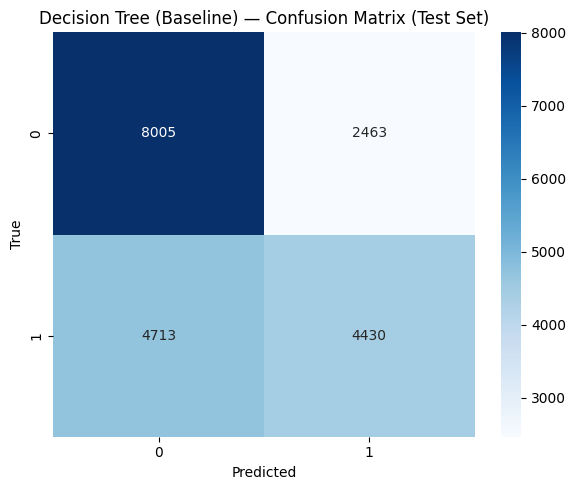

In [14]:
# Confusion matrix heatmap (Baseline Decision Tree)
cm = confusion_matrix(y_test, y_test_pred)
classes = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Decision Tree (Baseline) — Confusion Matrix (Test Set)")

plt.tight_layout()
plt.show()

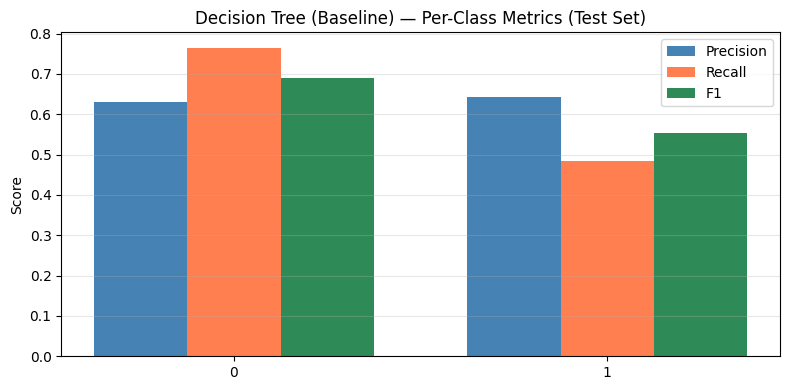

In [15]:
# Per-class precision, recall, F1 (Baseline Decision Tree)
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, labels=classes
)

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, precision, width, label="Precision", color="steelblue")
ax.bar(x, recall, width, label="Recall", color="coral")
ax.bar(x + width, f1, width, label="F1", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Score")
ax.set_title("Decision Tree (Baseline) — Per-Class Metrics (Test Set)")

ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()